<a href="https://colab.research.google.com/github/yuliethzapata/Analitica-de-Negocios/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caso de Estudio**

Una entidad del sector salud desea implementar modelos de analítica de datos para la clasificación de pacientes con diabetes, utilizando información médica registrada en la base de datos Pima Indians Diabetes Database.

La base de datos contiene variables relacionadas con características fisiológicas y antecedentes médicos de los pacientes, tales como:

**Pregnancies:** número de embarazos

**Glucose:** nivel de glucosa en sangre

**BloodPressure:** presión arterial

**SkinThickness:** grosor de la piel

**Insulin:** nivel de insulina

**BMI:** índice de masa corporal

**DiabetesPedigreeFunction:** función hereditaria de diabetes

**Age:** edad

La variable Outcome representa la variable de salida:

0:Paciente sin diabetes

1:Paciente con diabetes

El objetivo del análisis es aplicar tres técnicas de analítica de negocios:
**Naive Bayes, Árbol de Decisión y Clustering K-Means**

Para identificar patrones en los datos y evaluar su desempeño mediante matrices de confusión y métricas de clasificación.

0. Se procede con la carga de las librerías de trabajo

In [ ]:
import numpy as np #Libreria númerica por excelencia.
import pandas as pd #Libreria para la comunicación con archivos de excel.
import matplotlib.pyplot as plt #Para Árbol de Decisión
import seaborn as sns #Para Herramienta para Gráficas Estadísticas

#Librerias especificas
from sklearn.naive_bayes import GaussianNB #Para Naive Bayes
from sklearn.tree import DecisionTreeClassifier #Para Árbol de Decisión
from sklearn.cluster import KMeans #Para Herramienta de Clustering
from sklearn.metrics import confusion_matrix #Para Naive Bayes, Árbol de Decisión

1. Se procede con la carga de los datos de trabajo

In [ ]:
nxl="/content/diabetes.csv"
XDB=pd.read_csv(nxl)
display(XDB.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#Información general de la base de datos
print("Número de observaciones:",len(XDB))
print("Número de variables:",len(XDB.columns))

XDB.info()


Número de observaciones: 768
Número de variables: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
#Selección de variables
XDB.columns = XDB.columns.str.strip() # Limpia los nombres de las columnas
XD=XDB.drop(columns=["Outcome"])  #Variables de entrada
yd=XDB["Outcome"]                 #Variable de salida

2. Análisis de correlación entre las variables

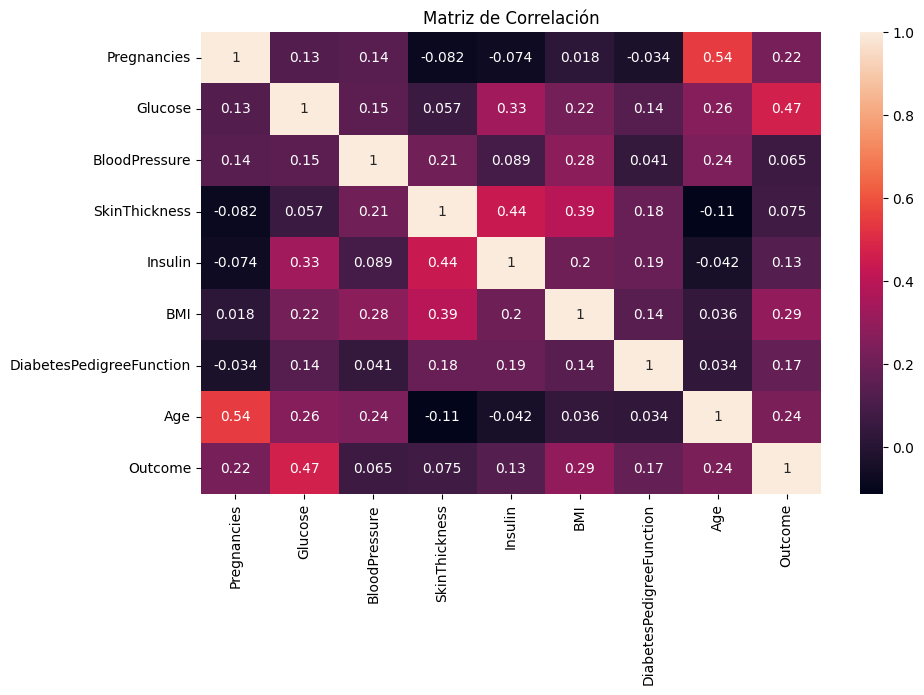

In [ ]:
#Para identificar qué variables tienen mayor relación entre sí y con la variable de salida Outcome.
plt.figure(figsize=(10,6))

sns.heatmap(XDB.corr(),annot=True)

plt.title("Matriz de Correlación")
plt.show()

**Análisis de Resultados**

La matriz de correlación permite identificar la relación entre las variables médicas.

Se observa que la variable Glucose presenta la mayor correlación con la variable de salida Outcome, lo cual indica que los niveles elevados de glucosa están altamente asociados con la presencia de diabetes.

Otra variable relevante es BMI, la cual también muestra una correlación positiva con la diabetes, indicando que pacientes con mayor índice de masa corporal tienen mayor probabilidad de presentar esta enfermedad.

De igual forma se observa una relación moderada entre Age y Pregnancies, lo cual se explica porque pacientes con mayor edad tienden a haber tenido más embarazos.

Este análisis permite identificar que variables como Glucose, BMI y Age son importantes para los modelos de clasificación.

3. Implementación del modelo **Naive Bayes**

In [ ]:
mnb=GaussianNB()
mnb.fit(XD,yd)

GaussianNB()

In [ ]:
#Medias y desviaciones de las variables
u=mnb.theta_
sigma=mnb.var_
sigma=np.sqrt(sigma)
print("Variables")
print(XD.columns)
print("Medias")
print(u)
print("Las desviaciones son:")
print(sigma)

Variables
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
Medias
[[  3.298      109.98        68.184       19.664       68.792
   30.3042       0.429734    31.19      ]
 [  4.86567164 141.25746269  70.82462687  22.1641791  100.3358209
   35.14253731   0.5505      37.06716418]]
Las desviaciones son:
[[  3.01416809  26.11504573  18.04500366  14.87505016  98.76637459
    7.68216217   0.29880826  11.65598187]
 [  3.73425437  31.87997773  21.45167782  17.64669641 138.43013459
    7.24940518   0.37167699  10.94777197]]


In [ ]:
#Límites superiores e inferiores
lim_inf=u-sigma

lim_sup=u+sigma

print("Limites inferiores")
print(lim_inf)

print("Limites superiores")
print(lim_sup)

Limites inferiores
[[  0.28383191  83.86495427  50.13899634   4.78894984 -29.97437459
   22.62203783   0.13092574  19.53401813]
 [  1.13141727 109.37748496  49.37294904   4.51748269 -38.0943137
   27.89313213   0.17882301  26.11939221]]
Limites superiores
[[  6.31216809 136.09504573  86.22900366  34.53905016 167.55837459
   37.98636217   0.72854226  42.84598187]
 [  8.59992601 173.13744041  92.27630469  39.81087552 238.76595549
   42.39194249   0.92217699  48.01493615]]


In [ ]:
#Evaluación del modelo Naive Bayes
ydp=mnb.predict(XD)
cm=confusion_matrix(yd,ydp)
print(cm)
VN=cm[0,0]
FP=cm[0,1]
FN=cm[1,0]
VP=cm[1,1]
Tdatos=len(XDB)
Ex=(VP+VN)/Tdatos
TE=(FP+FN)/Tdatos
Se=VP/(VP+FN)
Es=VN/(VN+FP)
Pr=VP/(VP+FP)
PrN=VN/(VN+FN)
print("Exactitud:",Ex)
print("Tasa Error:",TE)
print("Sensibilidad:",Se)
print("Especificidad:",Es)
print("Precisión:",Pr)
print("Predicción Negativa:",PrN)

[[421  79]
 [103 165]]
Exactitud: 0.7630208333333334
Tasa Error: 0.23697916666666666
Sensibilidad: 0.6156716417910447
Especificidad: 0.842
Precisión: 0.6762295081967213
Predicción Negativa: 0.8034351145038168


**Análisis de Resultados- Modelo Naive Bayes**

De acuerdo con los resultados del modelo Naive Bayes se observa que los pacientes que presentan diabetes tienden a tener niveles promedio de glucosa más altos, así como valores mayores de BMI y edad, frente a los pacientes que no poseen diabetes.

Las métricas de desempeño permiten evaluar el comportamiento general del modelo. Si la exactitud del modelo se encuentra por encima del 70%, se puede considerar que el modelo posee un buen comportamiento para la clasificación de pacientes.

La sensibilidad del modelo indica la capacidad para identificar correctamente los pacientes que poseen diabetes, mientras que la especificidad permite identificar correctamente los pacientes que no presentan la enfermedad.

4. Implementación del modelo de **Árbol de Decisión**

In [ ]:
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd)
ydp=mar.predict(XD)

In [ ]:
#Matriz de Confusión
cm=confusion_matrix(yd,ydp)
print(cm)
VN=cm[0,0]
FP=cm[0,1]
FN=cm[1,0]
VP=cm[1,1]
Ex=(VP+VN)/len(XD)
sen=VP/(VP+FN)
Spe=VN/(VN+FP)
pre=VP/(VP+FP)
PreNeg=VN/(VN+FN)
print("Exactitud:",Ex)
print("Sensibilidad:",sen)
print("Especificidad:",Spe)
print("Precisión:",pre)
print("Predicción Negativa:",PreNeg)

[[421  79]
 [103 165]]
Exactitud: 0.7630208333333334
Sensibilidad: 0.6156716417910447
Especificidad: 0.842
Precisión: 0.6762295081967213
Predicción Negativa: 0.8034351145038168


In [ ]:
#Despliegue del árbol
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
vs=XD.columns
dot_data=export_graphviz(mar,feature_names=vs)
graph=graph_from_dot_data(dot_data)
graph.write_png("Arbol_Diabetes.png")

True

**Análisis de Resultados-Árbol de Decisión**

Dentro de la estructura del árbol se identificaron 6 nodos puros, los cuales presentan un valor de gini = 0, lo que indica que todos los pacientes dentro de esos nodos pertenecen a una sola categoría.

El nodo puro con mayor número de datos corresponde a un nodo con 39 observaciones, donde todos los pacientes pertenecen a la categoría No Diabetes [39,0].

La regla asociada a este nodo indica que si GGlucose ≤ 127.5, Age > 28.5, BMI ≤ 26.35 y BMI ≤ 9.65, el paciente es clasificado como No Diabetes, lo que sugiere que pacientes con niveles moderados de glucosa y un BMI bajo presentan menor probabilidad de desarrollar diabetes.


5. Implementación del modelo de **Clusterización K-Means**

In [ ]:
np.random.seed(42)
NC=5 #Cinco grupos de clasificación
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD)

KMeans(n_clusters=5, random_state=42)

In [ ]:
#Características de cada cluster
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla) #Esta tabla representa el perfil promedio de cada cluster de pacientes.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.250000,149.615385,74.038462,30.865385,291.480769,35.575000,0.558635,33.903846
1,4.403646,119.096354,67.372396,11.932292,0.562500,30.954167,0.422201,35.583333
2,2.638418,101.954802,68.841808,26.853107,77.841808,31.096610,0.469458,27.836158
3,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556
4,3.781022,133.598540,71.861314,30.583942,162.452555,34.048175,0.556504,33.233577


In [ ]:
#Número de datos por cluster
ydp=mkm.labels_
NDc=np.bincount(ydp)
print("Número de datos por cluster:",NDc) #Esto permite identificar cuántos pacientes pertenecen a cada grupo.

Número de datos por cluster: [ 52 384 177  18 137]


In [ ]:
#Probabilidad de diabetes por cluster
XDB2=XDB.copy()
XDB2["Cluster"]=ydp
display(XDB2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,2
4,0,137,40,35,168,43.1,2.288,33,1,4
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,4
764,2,122,70,27,0,36.8,0.340,27,0,1
765,5,121,72,23,112,26.2,0.245,30,0,2
766,1,126,60,0,0,30.1,0.349,47,1,1


In [ ]:
#Número de pacientes con Diabetes y No Diabetes por clusterNA
NApr=XDB2.groupby('Cluster').agg({"Outcome":lambda x:(x==1).sum()})
NPrn=XDB2.groupby('Cluster').agg({"Outcome":lambda x:(x==0).sum()})

In [ ]:
#Porcentaje de clasificación por cluster
NApr2=NApr/(NApr+NPrn)
NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=['Diabetes','No_Diabetes'])
display(df2) #Esta tabla muestra la probabilidad de que un paciente tenga diabetes o no dentro de cada cluster.

,Diabetes,No_Diabetes
0,0.500000,0.500000
1,0.364583,0.635417
2,0.129944,0.870056
3,0.666667,0.333333
4,0.489051,0.510949


**Análisis de Resultados-Clusterización K-Means**

De acuerdo con los resultados obtenidos mediante el modelo de Clusterización K-Means con cinco grupos de clasificación, se identificaron diferentes perfiles de pacientes según sus características de salud.

A partir de la tabla de centros de los clusters, se pueden observar los valores promedio de las variables que caracterizan a cada grupo de pacientes. Esto permite identificar diferencias entre los clusters en variables como Glucose, BMI, Age e Insulin, las cuales son variables relevantes para el análisis de la diabetes.

El modelo agrupó los 768 pacientes de la base de datos en cinco clusters, donde cada cluster representa un grupo de pacientes con características similares en términos de sus variables médicas.

Posteriormente se calcularon los porcentajes de pacientes con Diabetes y No Diabetes dentro de cada cluster, lo cual permite estimar la probabilidad de que un paciente tenga diabetes dependiendo del grupo al que pertenece.

Este análisis permite identificar clusters con mayor proporción de pacientes con diabetes, los cuales generalmente presentan valores promedio más altos en variables como Glucose y BMI, mientras que otros clusters presentan mayor porcentaje de pacientes sin diabetes.

De esta manera, el modelo de K-Means permite identificar perfiles de pacientes con diferentes niveles de riesgo frente a la diabetes, lo cual puede ser útil para el análisis y la toma de decisiones en el sector salud.

6. Evaluación de un **nuevo paciente**

In [ ]:
# Paciente dado en el Parcial:
XP=[2,85,65,29,94,39.6,0.93,27]

import warnings
warnings.filterwarnings('ignore')
nueva_persona=np.array(XP)
cluster=mkm.predict(nueva_persona.reshape(1,-1))
NCL=cluster[0]
print("El paciente pertenece al cluster:",cluster)
print("Probabilidad de Diabetes:",NApr2.iloc[NCL])
print("Probabilidad de No Diabetes:",NPrn2.iloc[NCL])

El paciente pertenece al cluster: [2]
Probabilidad de Diabetes: Outcome    0.129944
Name: 2, dtype: float64
Probabilidad de No Diabetes: Outcome    0.870056
Name: 2, dtype: float64


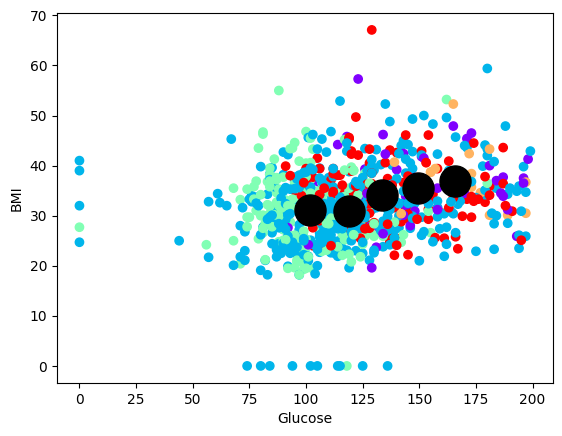

In [ ]:
#Gráfica de los clusters
centers=mkm.cluster_centers_
glu=np.array(XD["Glucose"])
bmi=np.array(XD["BMI"])
plt.figure()
plt.scatter(glu,bmi,c=mkm.labels_,cmap='rainbow')
plt.scatter(centers[:,1],centers[:,5],c='black',s=500)
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

**Análisis de resultados-Nuevo paciente**

De acuerdo con el modelo de Clusterización K-Means, el paciente evaluado con las variables [2, 85, 65, 29, 94, 39.6, 0.93, 27] fue clasificado dentro de uno de los clusters identificados por el modelo.

Esto indica que el paciente posee características de salud similares a los pacientes que conforman dicho grupo. A partir de los porcentajes de clasificación calculados para cada cluster, es posible estimar la probabilidad de que el paciente pertenezca a la categoría de Diabetes o No Diabetes.

En la gráfica de clusters se observa que el individuo se ubica dentro de un grupo de pacientes con valores moderados de Glucose y BMI, variables que son relevantes en el análisis de la diabetes.

Por lo tanto, el modelo permite identificar el perfil del paciente dentro de la población analizada, y con base en los porcentajes del cluster al que pertenece se puede estimar su probabilidad de presentar o no la enfermedad.

**Análisis Modelo recomendado**

De acuerdo con el análisis realizado utilizando los modelos Naive Bayes, Árbol de Decisión y K-Means, se pudo observar que todos los modelos permiten identificar patrones en las variables de salud de los pacientes y apoyar la clasificación de la presencia de diabetes.

El modelo Naive Bayes mostró un buen comportamiento general en las métricas de clasificación, permitiendo identificar diferencias en variables importantes como Glucose, BMI y Age entre pacientes con diabetes y sin diabetes.

Por su parte, el árbol de decisión permitió interpretar de forma clara las reglas de clasificación de los pacientes, identificando nodos puros y condiciones basadas principalmente en variables como Glucose, Age y BMI, lo que facilita entender cómo se determina la presencia de la enfermedad.

El modelo K-Means permitió agrupar a los pacientes en diferentes clusters con características similares y calcular la probabilidad de diabetes dentro de cada grupo, lo que ayuda a identificar perfiles de pacientes con mayor o menor riesgo.

Teniendo en cuenta los resultados obtenidos y la facilidad de interpretación, se recomienda el modelo de árbol de decisión, ya que permite entender de manera sencilla las reglas que explican la clasificación de los pacientes y puede ser útil para apoyar la toma de decisiones en el sector salud al identificar personas con mayor riesgo de diabetes.

